## EDA On Fertility Health Dataset

In [409]:
#importing Libraries
#import filterwarnings from warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

In [371]:
#Loading dataSet
df = pd.read_csv(r"D:\Machine_learning\DataSet\fer_modified.csv",header=0,index_col=0)

In [372]:
df.head(10)

,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success,Testosterone_Level,Varicocele_Presence,Heat_Exposure,Diet_Quality_Score,Avg_Sitting_Hours
Couple_ID,,,,,,,,,,,,,,,,,,,,,,,
CPL0001,26.0,32,21.1,30.4,No,Regular,5.0,5.4,1,21.6,81.0,No,No,Moderate,Low,Light,Moderate,Failure,539.6,No,6.1,4.5,8.4
CPL0002,39.0,40,24.1,25.6,No,Regular,4.8,5.1,0,41.5,56.8,No,Yes,Low,Moderate,Light,Light,Failure,516.6,No,5.8,5.0,8.8
CPL0003,34.0,42,25.4,27.0,Yes,Irregular,5.1,5.0,3,64.5,50.8,No,No,No_Alcohol,Low,Light,Moderate,Success,611.8,No,4.8,6.1,7.2
CPL0004,30.0,35,28.7,26.7,No,Regular,5.4,5.5,2,80.2,46.6,No,No,Moderate,Low,No_Exercise,Moderate,Success,709.2,No,4.7,6.9,7.0
CPL0005,27.0,35,25.1,24.1,Yes,Irregular,4.6,5.6,3,97.2,53.1,No,Yes,Low,Low,Active,Moderate,Failure,733.1,Yes,3.9,7.0,6.4
CPL0006,40.0,40,26.6,27.1,Yes,NaN,6.6,5.8,2,50.5,66.3,Yes,No,Low,Low,No_Exercise,Moderate,Failure,575.8,Yes,5.4,6.1,7.3
CPL0007,26.0,35,26.6,27.7,No,Regular,5.0,4.9,2,72.0,27.6,No,Yes,No_Alcohol,Moderate,Light,Light,Success,606.2,No,5.6,4.2,9.1
CPL0008,45.0,40,34.8,26.4,No,Regular,5.2,4.7,0,37.8,58.5,No,No,No_Alcohol,Moderate,No_Exercise,Light,Failure,532.2,Yes,7.0,4.4,8.8
CPL0009,38.0,38,16.8,28.2,No,Regular,5.8,5.8,2,47.4,47.4,No,Yes,No_Alcohol,Moderate,Light,Light,Failure,491.7,No,5.6,5.0,8.2


In [373]:
df.tail(10)

,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success,Testosterone_Level,Varicocele_Presence,Heat_Exposure,Diet_Quality_Score,Avg_Sitting_Hours
Couple_ID,,,,,,,,,,,,,,,,,,,,,,,
CPL1991,33.0,32,18.3,25.5,No,Regular,5.9,4.6,1,46.1,72.3,No,Yes,No_Alcohol,Low,Active,Moderate,Failure,598.9,Yes,6.4,6.2,6.5
CPL1992,44.0,44,21.9,26.2,No,Regular,5.0,6.0,1,53.4,56.2,No,No,No_Alcohol,Moderate,Moderate,Light,Failure,537.9,No,5.6,4.7,7.6
CPL1993,NaN,41,21.9,30.8,No,Regular,7.0,4.5,0,43.9,43.9,No,Yes,High,Moderate,No_Exercise,Light,Failure,470.7,No,6.8,3.8,8.4
CPL1994,40.0,43,28.1,30.8,Yes,Irregular,6.6,4.1,2,34.2,28.2,No,Yes,Low,High,No_Exercise,No_Exercise,Failure,457.8,Yes,5.7,3.6,10.1
CPL1995,27.0,33,19.7,25.4,Yes,Irregular,5.9,4.7,1,57.9,48.6,No,Yes,Moderate,Moderate,Light,Light,Failure,488.1,No,6.9,6.2,9.1
CPL1996,34.0,35,20.8,27.0,Yes,NaN,5.8,6.4,0,61.2,67.1,No,Yes,Low,Low,Moderate,Moderate,Failure,631.7,No,6.6,6.0,5.8
CPL1997,33.0,42,24.9,25.9,Yes,Irregular,5.5,3.8,0,52.9,39.8,No,Yes,Low,Moderate,Moderate,Light,Failure,498.0,No,6.2,4.6,9.9
CPL1998,37.0,40,18.7,28.2,Yes,Irregular,6.1,4.9,2,17.6,65.2,No,No,Low,Moderate,Light,Light,Failure,473.9,No,5.3,5.1,10.2
CPL1999,39.0,39,21.4,26.4,No,Regular,7.1,6.1,1,NaN,55.4,No,No,No_Alcohol,Moderate,Active,Light,Success,555.9,Yes,6.0,4.4,8.1


In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, CPL0001 to CPL2000
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Female_Age            1801 non-null   float64
 1   Male_Age              2000 non-null   int64  
 2   Female_BMI            2000 non-null   float64
 3   Male_BMI              2000 non-null   float64
 4   PCOS                  2000 non-null   object 
 5   Period_Regularity     1822 non-null   object 
 6   Stress_Level          2000 non-null   float64
 7   Sleep_Quality         2000 non-null   float64
 8   Past_Pregnancies      2000 non-null   int64  
 9   Sperm_Count_M_per_mL  1791 non-null   float64
 10  Sperm_Motility_Pct    2000 non-null   float64
 11  Female_Smokes         2000 non-null   object 
 12  Male_Smokes           2000 non-null   object 
 13  Female_Alcohol        2000 non-null   object 
 14  Male_Alcohol          2000 non-null   object 
 15  Female_Exercise  

In [375]:
df.isnull().any()

Female_Age               True
Male_Age                False
Female_BMI              False
Male_BMI                False
PCOS                    False
Period_Regularity        True
Stress_Level            False
Sleep_Quality           False
Past_Pregnancies        False
Sperm_Count_M_per_mL     True
Sperm_Motility_Pct      False
Female_Smokes           False
Male_Smokes             False
Female_Alcohol          False
Male_Alcohol            False
Female_Exercise         False
Male_Exercise           False
Pregnancy_Success       False
Testosterone_Level      False
Varicocele_Presence     False
Heat_Exposure           False
Diet_Quality_Score      False
Avg_Sitting_Hours       False
dtype: bool

In [376]:
df.isnull().sum()

Female_Age              199
Male_Age                  0
Female_BMI                0
Male_BMI                  0
PCOS                      0
Period_Regularity       178
Stress_Level              0
Sleep_Quality             0
Past_Pregnancies          0
Sperm_Count_M_per_mL    209
Sperm_Motility_Pct        0
Female_Smokes             0
Male_Smokes               0
Female_Alcohol            0
Male_Alcohol              0
Female_Exercise           0
Male_Exercise             0
Pregnancy_Success         0
Testosterone_Level        0
Varicocele_Presence       0
Heat_Exposure             0
Diet_Quality_Score        0
Avg_Sitting_Hours         0
dtype: int64

In [377]:
df.describe()

,Female_Age,Male_Age,Female_BMI,Male_BMI,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Testosterone_Level,Heat_Exposure,Diet_Quality_Score,Avg_Sitting_Hours
count,1801.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,1791.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.00000
mean,32.540255,36.562500,23.975300,27.875450,5.56445,5.558050,0.776500,51.018090,55.23645,548.796150,5.671800,5.266900,8.55500
std,7.658159,4.402588,3.911116,2.606826,1.03458,1.010829,0.906619,19.755277,14.85918,83.922451,1.101363,1.052149,1.54139
min,20.000000,23.000000,16.000000,18.400000,2.30000,2.100000,0.000000,1.000000,12.00000,210.000000,2.400000,1.300000,3.40000
25%,26.000000,33.000000,21.200000,26.200000,4.80000,4.900000,0.000000,37.900000,44.97500,493.875000,4.900000,4.600000,7.50000
50%,33.000000,36.000000,24.000000,27.800000,5.60000,5.600000,1.000000,51.100000,54.90000,547.900000,5.700000,5.300000,8.50000
75%,39.000000,40.000000,26.700000,29.600000,6.30000,6.200000,1.000000,64.300000,65.20000,604.125000,6.400000,6.000000,9.50000
max,45.000000,48.000000,36.200000,37.000000,9.10000,9.600000,3.000000,120.000000,95.00000,882.300000,9.600000,9.400000,14.40000


Text(0.5, 1.0, 'Multivariate box plot')

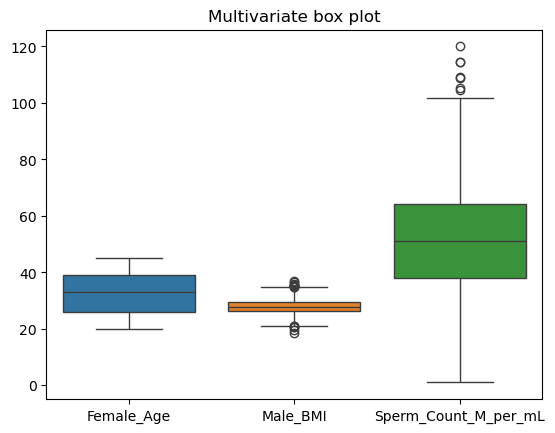

In [378]:
# checking that Female Age is affected by outliers or not by ploting box plot.
sns.boxplot(data=df[["Female_Age",'Male_BMI','Sperm_Count_M_per_mL']])
plt.title("Multivariate box plot")

In [379]:
#filling null values through mean because there are not any outlier present in columns which we are filling.
df.Female_Age.fillna(df['Female_Age'].mean().sum(),inplace=True)
df.Male_BMI.fillna(df['Male_BMI'].mean().sum(),inplace=True)
df.Sperm_Count_M_per_mL.fillna(df.Sperm_Count_M_per_mL.mean().sum(),inplace=True)

C:\Users\manis\AppData\Local\Temp\ipykernel_13584\2522380613.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\manis\AppData\Local\Temp\ipykernel_13584\2522380613.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [380]:
df['Sperm_Count_M_per_mL'].mean()

np.float64(51.018090452261305)

In [381]:
df.Period_Regularity.fillna("not_specified",inplace=True)

C:\Users\manis\AppData\Local\Temp\ipykernel_13584\2029532877.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [382]:
#checking missing values again.
df.isnull().any()

Female_Age              False
Male_Age                False
Female_BMI              False
Male_BMI                False
PCOS                    False
Period_Regularity       False
Stress_Level            False
Sleep_Quality           False
Past_Pregnancies        False
Sperm_Count_M_per_mL    False
Sperm_Motility_Pct      False
Female_Smokes           False
Male_Smokes             False
Female_Alcohol          False
Male_Alcohol            False
Female_Exercise         False
Male_Exercise           False
Pregnancy_Success       False
Testosterone_Level      False
Varicocele_Presence     False
Heat_Exposure           False
Diet_Quality_Score      False
Avg_Sitting_Hours       False
dtype: bool

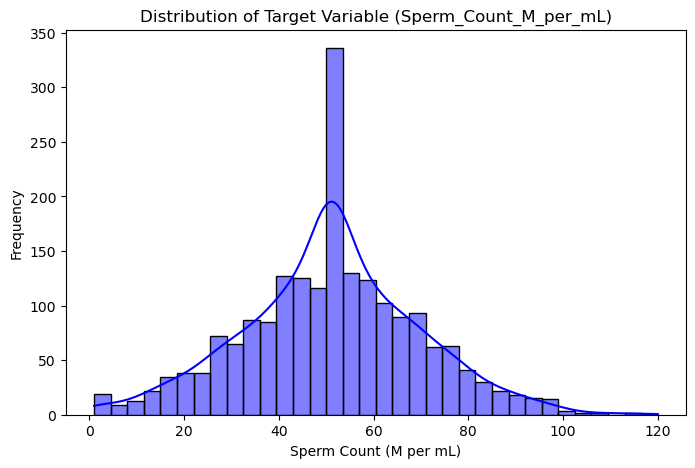

In [383]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sperm_Count_M_per_mL'].dropna(), kde=True, color='blue')
plt.title('Distribution of Target Variable (Sperm_Count_M_per_mL)')
plt.xlabel('Sperm Count (M per mL)')
plt.ylabel('Frequency')
plt.savefig('target_distribution.png')

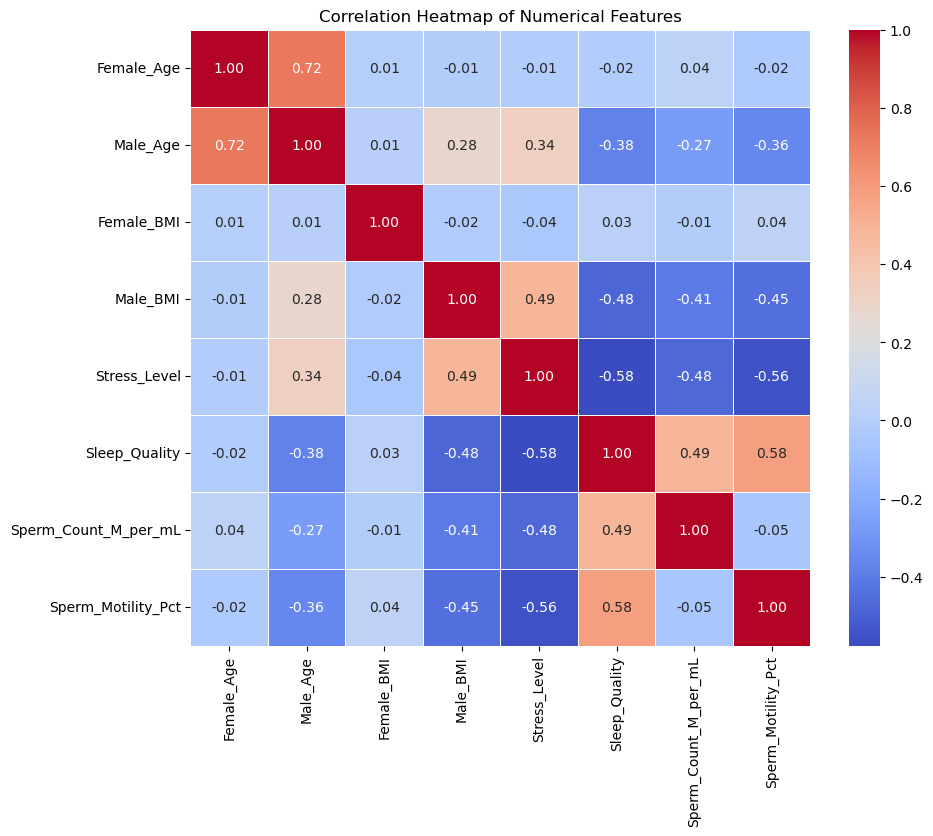

In [384]:
plt.figure(figsize=(10, 8))
# Selecting only numerical columns
numerical_cols = ['Female_Age', 'Male_Age', 'Female_BMI', 'Male_BMI', 'Stress_Level', 
                  'Sleep_Quality', 'Sperm_Count_M_per_mL', 'Sperm_Motility_Pct']
corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png')

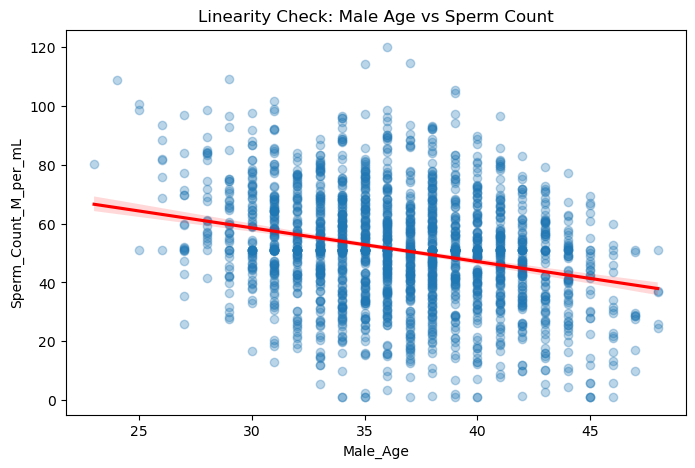

In [385]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Male_Age', y='Sperm_Count_M_per_mL', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Linearity Check: Male Age vs Sperm Count')
plt.savefig('linearity_check.png')
#checks if there is a linear relationship between a predictor (e.g., Male Age) and the target.

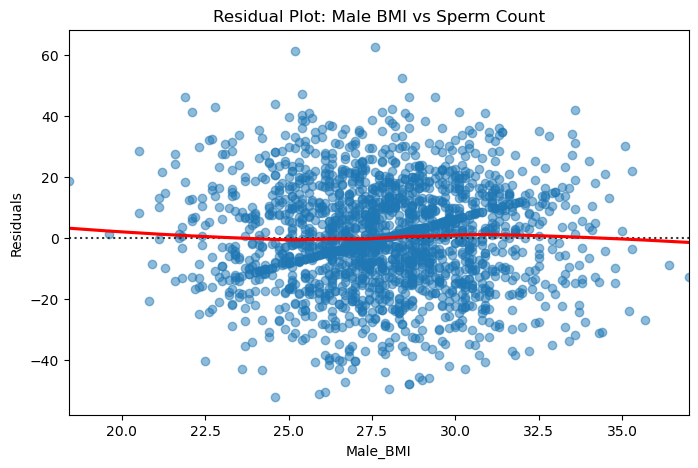

In [386]:
#Homoscedasticity means the errors remain constant across all values of the independent variable.  
#  If this plot shows a funnel shape, your model is violating this assumption.

plt.figure(figsize=(8, 5))
sns.residplot(x='Male_BMI', y='Sperm_Count_M_per_mL', data=df, lowess=True, 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Residual Plot: Male BMI vs Sperm Count')
plt.ylabel('Residuals')
plt.savefig('residual_plot.png')

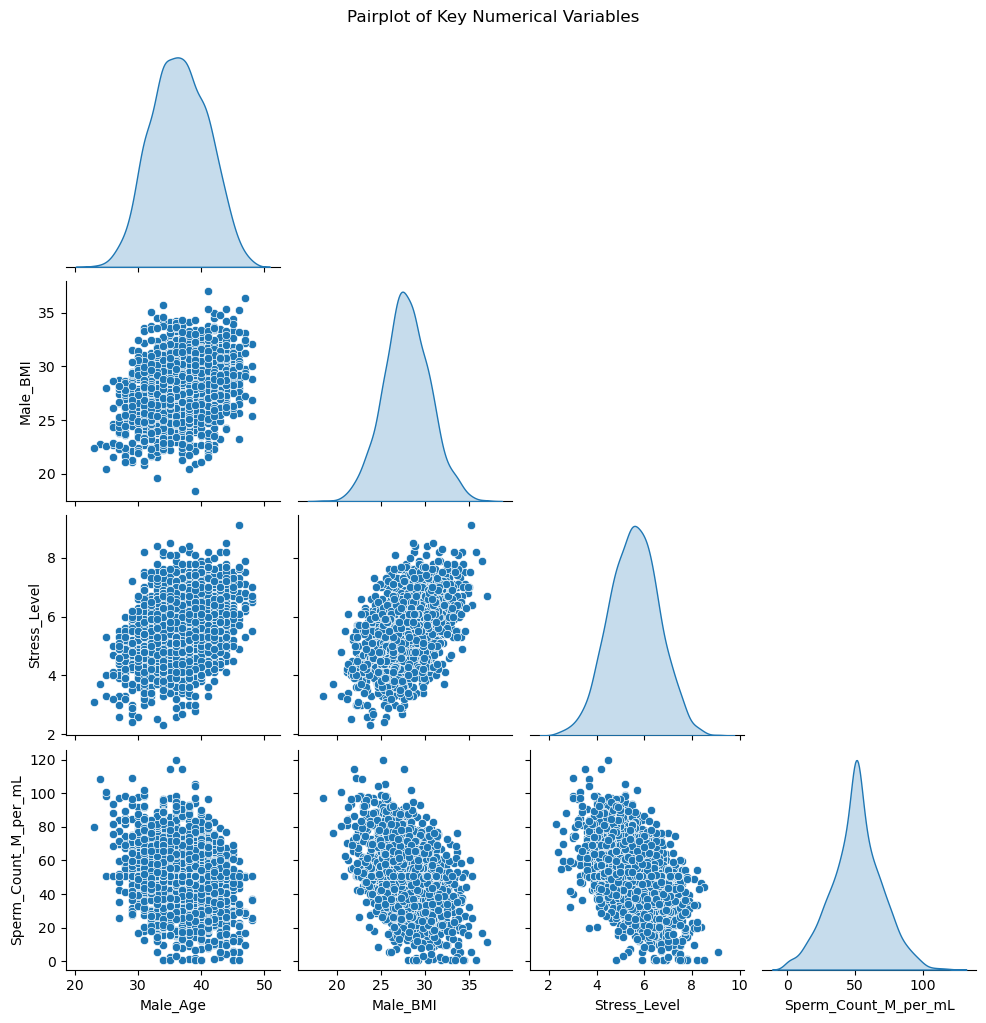

In [387]:
#A pairplot gives you a bird's-eye view of how multiple numerical variables interact with each other all at once.
# Subset to avoid a massive, unreadable image
subset = df[['Male_Age', 'Male_BMI', 'Stress_Level', 'Sperm_Count_M_per_mL']].dropna()

sns.pairplot(subset, diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Key Numerical Variables', y=1.02)
plt.savefig('pairplot_overview.png')

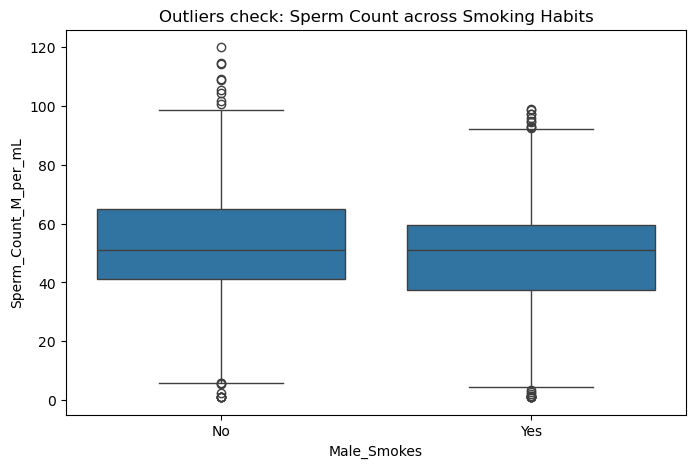

In [388]:
#Outliers can heavily skew a Linear Regression model.   
# Boxplots are the best way to visualize outliers across different categorical groups
plt.figure(figsize=(8, 5))
# Sorting the x-axis to keep bars ordered
sns.boxplot(x=df['Male_Smokes'].sort_values(), y=df['Sperm_Count_M_per_mL'])
plt.title('Outliers check: Sperm Count across Smoking Habits')
plt.savefig('boxplot_outliers.png')

C:\Users\manis\AppData\Local\Temp\ipykernel_13584\3640865883.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




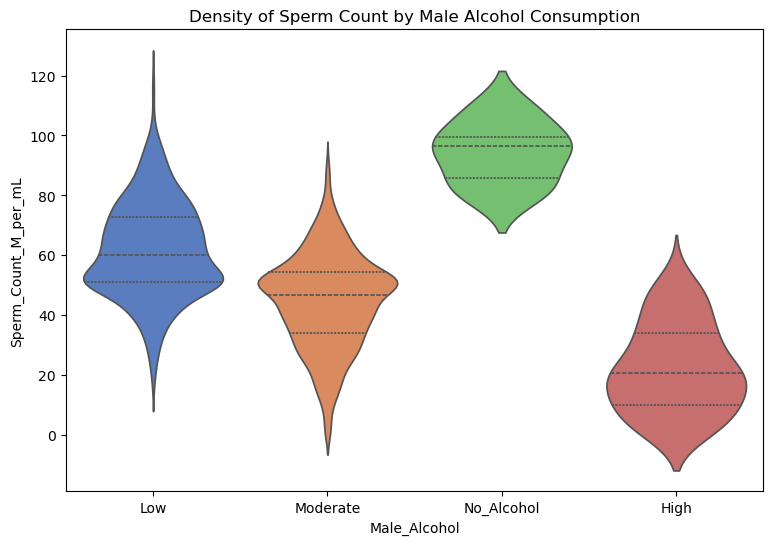

In [389]:
# Similar to a boxplot, but a violin plot also shows the probability density of the data at different values.

plt.figure(figsize=(9, 6))
sns.violinplot(x=df['Male_Alcohol'].sort_values(), y=df['Sperm_Count_M_per_mL'], 
               palette='muted', inner='quartile')
plt.title('Density of Sperm Count by Male Alcohol Consumption')
plt.savefig('violin_plot.png')

In [390]:
# When evaluating two predictors against a target, 
# an interactive 3D plot allows you to rotate the graph and visually identify spatial trends or planes.

import plotly.express as px

# Drop NaNs for a clean Plotly render
df_clean = df.dropna(subset=['Male_Age', 'Male_BMI', 'Sperm_Count_M_per_mL'])

fig = px.scatter_3d(df_clean, x='Male_Age', y='Male_BMI', z='Sperm_Count_M_per_mL',
                    color='Stress_Level', opacity=0.7,
                    title='3D Interaction: Age, BMI, and Sperm Count')
# In a local environment, this will open in your browser
fig.show()

In [391]:
# Plotly is excellent for splitting distributions side-by-side (faceting) 
# to see how an independent variable's distribution shifts based on a category.

fig2 = px.histogram(df, x='Sperm_Count_M_per_mL', color='Pregnancy_Success', 
                    barmode='overlay', marginal='box',
                    title='Interactive Sperm Count Distribution by Pregnancy Success')
fig2.show()

In [392]:
# Altair is perfect for creating interactive, 
# web-friendly visualizations where hovering over data points reveals exactly which rows might be outliers.

import altair as alt

# Using a subset of rows to keep rendering fast
df_alt = df[['Male_Age', 'Sperm_Count_M_per_mL', 'Male_Alcohol']].dropna().head(500)

chart = alt.Chart(df_alt).mark_circle(size=60).encode(
    x=alt.X('Male_Age', title='Male Age'),
    y=alt.Y('Sperm_Count_M_per_mL', title='Sperm Count'),
    color='Male_Alcohol',
    tooltip=['Male_Age', 'Sperm_Count_M_per_mL', 'Male_Alcohol']
).interactive().properties(
    title='Interactive Scatter: Age vs Sperm Count by Alcohol',
    width=600,
    height=400
)

# Just type the variable name to display it inline!
chart

alt.Chart(...)

In [393]:
# Label Encoding for converting categorical Columns to Numeric.

le = LabelEncoder()

c_col = ["PCOS","Period_Regularity","Female_Smokes","Male_Smokes","Female_Alcohol","Male_Alcohol","Varicocele_Presence",
         "Female_Exercise","Male_Exercise","Pregnancy_Success"]

for i in c_col:
    df[i] = le.fit_transform(df[i])

In [394]:
df.head()

,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success,Testosterone_Level,Varicocele_Presence,Heat_Exposure,Diet_Quality_Score,Avg_Sitting_Hours
Couple_ID,,,,,,,,,,,,,,,,,,,,,,,
CPL0001,26.0,32,21.1,30.4,0,1,5.0,5.4,1,21.6,81.0,0,0,2,1,1,2,0,539.6,0,6.1,4.5,8.4
CPL0002,39.0,40,24.1,25.6,0,1,4.8,5.1,0,41.5,56.8,0,1,1,2,1,1,0,516.6,0,5.8,5.0,8.8
CPL0003,34.0,42,25.4,27.0,1,0,5.1,5.0,3,64.5,50.8,0,0,3,1,1,2,1,611.8,0,4.8,6.1,7.2
CPL0004,30.0,35,28.7,26.7,0,1,5.4,5.5,2,80.2,46.6,0,0,2,1,3,2,1,709.2,0,4.7,6.9,7.0
CPL0005,27.0,35,25.1,24.1,1,0,4.6,5.6,3,97.2,53.1,0,1,1,1,0,2,0,733.1,1,3.9,7.0,6.4


In [395]:
# df.drop(df[["Female_Age","Female_BMI","PCOS","Period_Regularity","Female_Smokes","Female_Alcohol","Female_Exercise","Past_Pregnancies"]],axis=1,inplace=True)
# #df.drop(df[['Female_Age','Female_BMI','PCOS',
#        'Period_Regularity', 'Stress_Level', 'Sleep_Quality',
#        'Past_Pregnancies',
#        'Female_Smokes','Female_Alcohol',
#        'Female_Exercise','Pregnancy_Success', 'Heat_Exposure',
#        'Diet_Quality_Score', 'Avg_Sitting_Hours']],axis=1,inplace=True)

In [396]:
# #df.drop(df[['Male_Age', 'Male_BMI', 'Sperm_Count_M_per_mL', 'Sperm_Motility_Pct',
#        'Male_Smokes', 'Male_Alcohol', 'Male_Exercise', 'Testosterone_Level',
#        'Varicocele_Presence']],axis=1,inplace=True)

In [397]:
df.columns

Index(['Female_Age', 'Male_Age', 'Female_BMI', 'Male_BMI', 'PCOS',
       'Period_Regularity', 'Stress_Level', 'Sleep_Quality',
       'Past_Pregnancies', 'Sperm_Count_M_per_mL', 'Sperm_Motility_Pct',
       'Female_Smokes', 'Male_Smokes', 'Female_Alcohol', 'Male_Alcohol',
       'Female_Exercise', 'Male_Exercise', 'Pregnancy_Success',
       'Testosterone_Level', 'Varicocele_Presence', 'Heat_Exposure',
       'Diet_Quality_Score', 'Avg_Sitting_Hours'],
      dtype='object')

In [398]:
#df.drop(df[["Female_Age","Female_BMI","PCOS","Period_Regularity","Female_Smokes","Female_Alcohol","Female_Exercise","Past_Pregnancies"]],axis=1,inplace=True)

In [399]:
x = df.drop("Sperm_Motility_Pct",axis=1)
y= df["Sperm_Motility_Pct"]

In [400]:
for size in [0.60, 0.70, 0.80]:
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=size, random_state=42)
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    y_pred = lr.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    print(f"Train Size: {size:.2f} -> R2 Score: {r2 * 100:.4f}%")

Train Size: 0.60 -> R2 Score: 83.2019%
Train Size: 0.70 -> R2 Score: 83.5230%
Train Size: 0.80 -> R2 Score: 81.9479%


In [401]:
lr = LinearRegression()

In [402]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [403]:
y_pred = lr.predict(x_test)

In [404]:
r2 = r2_score(y_test,y_pred)
r2*100

81.94785567266106

In [405]:
mae = mean_absolute_error(y_test,y_pred)
mae

4.841901305869138

In [406]:
mse_l1 = mean_squared_error(y_test,y_pred)
mse_l1

36.31387292205926

In [407]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

6.026099312329599

In [408]:
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.09373178946618105